In [102]:
from Bio import Entrez, Blast, SeqIO
import re
import json
import pandas as pd
from pandas.core.interchange.dataframe_protocol import DataFrame


In [2]:
Entrez.email = "blucardi@gmail.com"

In [3]:
blast_results_filename = "blast_results/TGY601W6014-Alignment(tblastn from web).xml"

# with open(blast_results_filename) as f:
#     blast_results_string = f.read()

blast_records = Blast.parse(blast_results_filename)
blast_records_list = list(blast_records)

In [4]:
print(blast_records)

Program: TBLASTN 2.17.0+
     db: core_nt

  Query: Query_8100162 (length=1258)
         AAA24823.1 ice nucleation protein [Pantoea agglomerans]
   Hits: No hits found

  Query: Query_8100163 (length=195)
         AAA49617.1 antifreeze polypeptide (AFP) precursor [Hemitripterus
         americanus]
   Hits: ----  -----  ----------------------------------------------------------
            #  # HSP  ID + description
         ----  -----  ----------------------------------------------------------
            0      1  gi|2700941652|ref|XM_063837581.1|  PREDICTED: Bolinopsi...
            1      1  gi|2700972406|ref|XM_063826959.1|  PREDICTED: Bolinopsi...
            2      2  gi|2700955919|ref|XM_063818157.1|  PREDICTED: Bolinopsi...
            3      1  gi|2700956383|ref|XM_063818403.1|  PREDICTED: Bolinopsi...
            4      1  gi|2700972404|ref|XM_063826957.1|  PREDICTED: Bolinopsi...
            5      1  gi|2700972402|ref|XM_063826956.1|  PREDICTED: Bolinopsi...
            6

In [58]:
print(blast_records[2][1])

Query: Query_8100164
       AAA49618.1 antifreeze protein [Hemitripterus americanus]
  Hit: gi|2700972406|ref|XM_063826959.1| (length=1285)
       PREDICTED: Bolinopsis microptera uncharacterized LOC134817717
       (LOC134817717), mRNA
 HSPs: ----  --------  ---------  ------  ---------------  ---------------------
          #   E-value  Bit score    Span      Query range              Hit range
       ----  --------  ---------  ------  ---------------  ---------------------
          0   1.4e-05      44.67      92         [56:129]                 [0:92]


In [97]:
reference_id = blast_records_list[2][1].target.id
reference_id

'gi|2700972406|ref|XM_063826959.1|'

In [186]:
reference_ids = []
for query in blast_records_list:
    for hit in query:
        reference_ids.append(hit.target.id)
# reference_ids

In [187]:
def sanitize_reference_id(reference_id):
    # Extract the part after the last '|'
    return reference_id.split("|")[-2]

In [188]:
search_string = ",".join([sanitize_reference_id(s) for s in set(reference_ids)])
search_string

'XM_063822536.1,XM_063822663.1,XM_063833069.1,XM_063837207.1,XM_063836312.1,XM_063833648.1,XM_063833072.1,XM_063826959.1,XM_063833404.1,XM_063817999.1,XM_063835162.1,XM_063838129.1,XM_063825900.1,XM_063826956.1,XM_063833071.1,XM_063832653.1,XM_063822534.1,XM_063824909.1,XM_063837581.1,XM_063826957.1,XM_063818403.1,XM_063832265.1,XM_063833070.1,XM_063832689.1,XM_063818157.1'

In [189]:
stream = Entrez.efetch(db="nucleotide", id=search_string, rettype="fasta_cds_na", retmode="text")
cdss = list(SeqIO.parse(stream, "fasta"))
stream.close()

# list(cdss)

locations = []
# {re.search(r"\[gene=([^\]]+)\]", s.description).group(1) : { "accessionID" : re.search(r"\|([^_]+_[^_]+)_", s.id).group(1)} for s in cdss }


for s in cdss:
    gene_name = re.search(r"\[gene=([^\]]+)\]", s.description).group(1)
    accession_id = re.search(r"\|([^_]+_[^_]+)_", s.id).group(1)

    # if gene_name not in locations:
    locations.append({"accessionID": accession_id, "locator": gene_name})
    # else:
    #     print(f"Warning: duplicate gene name {gene_name} found. Overwriting previous entry.")
    #     locations[gene_name]["accessionID"] = accession_id

df = pd.DataFrame(locations)

search_string = ",".join(list(df["locator"]))




In [190]:
df

,accessionID,locator
0,XM_063822536.1,LOC134814426
1,XM_063822663.1,LOC134814511
2,XM_063833069.1,LOC134822162
3,XM_063837207.1,LOC134825079
4,XM_063836312.1,LOC134824410
5,XM_063833648.1,LOC134822539
6,XM_063833072.1,LOC134822162
7,XM_063826959.1,LOC134817717
8,XM_063833404.1,LOC134822376
9,XM_063817999.1,LOC134811229


In [191]:
search_string

'LOC134814426,LOC134814511,LOC134822162,LOC134825079,LOC134824410,LOC134822539,LOC134822162,LOC134817717,LOC134822376,LOC134811229,LOC134823628,LOC134825929,LOC134816896,LOC134817716,LOC134822162,LOC134821842,LOC134814423,LOC134816142,LOC134825402,LOC134817716,LOC134811532,LOC134821560,LOC134822162,LOC134821881,LOC134811364'

In [192]:
stream = Entrez.efetch(db="gene", id=search_string, rettype="full", retmode="text")
# records = SeqIO.parse(stream, "text")
# accessions = {sequence.id: sequence for sequence in records}
# stream.close()
# record = Entrez.read(stream)
# print(accessions)
data = stream.read()
print(data)
# print(record)


1. LOC134814426
uncharacterized LOC134814426 [Bolinopsis microptera]
Other Designations: uncharacterized protein LOC134814426
Chromosome: 4
Annotation: Chromosome 4 NC_087075.1 (4098515..4119964)
ID: 134814426

2. LOC134814511
uncharacterized LOC134814511 [Bolinopsis microptera]
Other Designations: uncharacterized protein LOC134814511
Chromosome: 4
Annotation: Chromosome 4 NC_087075.1 (1605540..1671361, complement)
ID: 134814511

3. LOC134822162
contactin-6-like [Bolinopsis microptera]
Other Designations: contactin-6-like
Chromosome: 10
Annotation: Chromosome 10 NC_087081.1 (3074461..3086221)
ID: 134822162

4. LOC134825079
uncharacterized LOC134825079 [Bolinopsis microptera]
Other Designations: uncharacterized protein LOC134825079
Chromosome: 13
Annotation: Chromosome 13 NC_087084.1 (344144..377661)
ID: 134825079

5. LOC134824410
C-type mannose receptor 2-like [Bolinopsis microptera]
Other Designations: C-type mannose receptor 2-like
Chromosome: 12
Annotation: Chromosome 12 NC_087083.

In [193]:
pattern = re.compile(
    r"(LOC\d+).*?\[(.+?)\].*?Chromosome:\s*(\d+).*?Annotation:\s*Chromosome\s*\d+\s+(NC_\d+\.\d+)\s*\((\d+)\.\.(\d+)",
    re.S
)

matches = pattern.findall(data)

output = []

for idx, (loc, species_name, chrom, accession, start, end) in enumerate(matches):
    print(loc, species_name, chrom, accession, start, end)

    output.append({
        "loc": loc,
        "chrom": chrom,
        "species_name": species_name,
        "start": start,
        "end": end,
        "accession": accession,
    })

new_thing = pd.DataFrame(output)

LOC134814426 Bolinopsis microptera 4 NC_087075.1 4098515 4119964
LOC134814511 Bolinopsis microptera 4 NC_087075.1 1605540 1671361
LOC134822162 Bolinopsis microptera 10 NC_087081.1 3074461 3086221
LOC134825079 Bolinopsis microptera 13 NC_087084.1 344144 377661
LOC134824410 Bolinopsis microptera 12 NC_087083.1 9865385 9866844
LOC134822539 Bolinopsis microptera 11 NC_087082.1 10873466 10886829
LOC134822162 Bolinopsis microptera 10 NC_087081.1 3074461 3086221
LOC134817717 Bolinopsis microptera 7 NC_087078.1 4412928 4417617
LOC134822376 Bolinopsis microptera 10 NC_087081.1 32969 38478
LOC134811229 Bolinopsis microptera 1 NC_087072.1 9537820 9539178
LOC134823628 Bolinopsis microptera 11 NC_087082.1 11034815 11079230
LOC134825929 Bolinopsis microptera 1 NC_087072.1 2007048 2010642
LOC134816896 Bolinopsis microptera 6 NC_087077.1 9742091 9752017
LOC134817716 Bolinopsis microptera 7 NC_087078.1 4343407 4412247
LOC134822162 Bolinopsis microptera 10 NC_087081.1 3074461 3086221
LOC134821842 Bolino

In [194]:
list(df["accessionID"])

['XM_063822536.1',
 'XM_063822663.1',
 'XM_063833069.1',
 'XM_063837207.1',
 'XM_063836312.1',
 'XM_063833648.1',
 'XM_063833072.1',
 'XM_063826959.1',
 'XM_063833404.1',
 'XM_063817999.1',
 'XM_063835162.1',
 'XM_063838129.1',
 'XM_063825900.1',
 'XM_063826956.1',
 'XM_063833071.1',
 'XM_063832653.1',
 'XM_063822534.1',
 'XM_063824909.1',
 'XM_063837581.1',
 'XM_063826957.1',
 'XM_063818403.1',
 'XM_063832265.1',
 'XM_063833070.1',
 'XM_063832689.1',
 'XM_063818157.1']

In [196]:
new_thing["accessionID"] = list(df["accessionID"])
df = new_thing

In [199]:
df

,loc,chrom,species_name,start,end,accession,accessionID
0,LOC134814426,4,Bolinopsis microptera,4098515,4119964,NC_087075.1,XM_063822536.1
1,LOC134814511,4,Bolinopsis microptera,1605540,1671361,NC_087075.1,XM_063822663.1
2,LOC134822162,10,Bolinopsis microptera,3074461,3086221,NC_087081.1,XM_063833069.1
3,LOC134825079,13,Bolinopsis microptera,344144,377661,NC_087084.1,XM_063837207.1
4,LOC134824410,12,Bolinopsis microptera,9865385,9866844,NC_087083.1,XM_063836312.1
5,LOC134822539,11,Bolinopsis microptera,10873466,10886829,NC_087082.1,XM_063833648.1
6,LOC134822162,10,Bolinopsis microptera,3074461,3086221,NC_087081.1,XM_063833072.1
7,LOC134817717,7,Bolinopsis microptera,4412928,4417617,NC_087078.1,XM_063826959.1
8,LOC134822376,10,Bolinopsis microptera,32969,38478,NC_087081.1,XM_063833404.1
9,LOC134811229,1,Bolinopsis microptera,9537820,9539178,NC_087072.1,XM_063817999.1


In [200]:
unique_species_names = set(df["species_name"])
unique_species_names

{'Bolinopsis microptera'}

In [201]:
species = {name: dict() for name in unique_species_names}

for name in unique_species_names:
    stream = Entrez.esearch(db="taxonomy", term=name, retmode="xml")
    results = Entrez.read(stream)
    print(results)

    # Just take the first id for the animal
    species[name] |= { "species_id" : results["IdList"][0]}

    # stream = Entrez.efetch(db="genome", id=species[name]["id"], retmode="xml")
    # results = Entrez.read(stream)
    # print(results)

    # handle = Entrez.elink(dbfrom="taxonomy", db="assembly", id=species[name]["id"], linkname="taxonomy_assembly")
    # record = Entrez.read(handle)

    handle = Entrez.esearch(db="assembly", term=f"txid{species[name]['species_id'] }[Organism]", retmax="1")
    record = Entrez.read(handle)
    print(record)

    assembly_ids = record["IdList"]

    handle = Entrez.esummary(db="assembly", id=",".join(assembly_ids), report="full")
    summary_records = Entrez.read(handle)
    genome_accession_id = summary_records["DocumentSummarySet"]["DocumentSummary"][0]['AssemblyAccession']
    # print()

    species[name] |= { "genome_accession_id" : genome_accession_id}
    handle.close()


species

{'Count': '1', 'RetMax': '1', 'RetStart': '0', 'IdList': ['2820187'], 'TranslationSet': [], 'TranslationStack': [{'Term': 'Bolinopsis microptera[All Names]', 'Field': 'All Names', 'Count': '1', 'Explode': 'N'}, 'GROUP'], 'QueryTranslation': 'Bolinopsis microptera[All Names]'}
{'Count': '1', 'RetMax': '1', 'RetStart': '0', 'IdList': ['14401481'], 'TranslationSet': [], 'TranslationStack': [{'Term': 'txid2820187[Organism]', 'Field': 'Organism', 'Count': '1', 'Explode': 'Y'}, 'GROUP'], 'QueryTranslation': 'txid2820187[Organism]'}


{'Bolinopsis microptera': {'species_id': '2820187',
  'genome_accession_id': 'GCF_026151205.1'}}

In [202]:
import urllib.request
chroms = {}
for key, specie in species.items():

    # search_handle = Entrez.esearch(db="nuccore", term=f"{specie['genome_accession_id']}[Assembly]", retmax=100)
    # search_results = Entrez.read(search_handle)
    # search_handle.close()
    #
    # id_list = search_results["IdList"]
    #
    # # Fetching as 'gb' (GenBank) allows parsing of names/lengths
    # fetch_handle = Entrez.efetch(db="nuccore", id=id_list, rettype="gb", retmode="text")

    # print(fetch_handle.read())


    search = Entrez.esearch(
        db="assembly",
        term=specie["genome_accession_id"],
        retmode="xml"
    )

    search_record = Entrez.read(search)
    uid = search_record["IdList"][0]

    print("UID:", uid)

    summary = Entrez.esummary(
        db="assembly",
        id=uid,
        retmode="xml"
    )

    record = Entrez.read(summary)
    print(record)

    # Generated, be careful
    # todo: reread for correctness.

    doc = record["DocumentSummarySet"]["DocumentSummary"][0]
    assembly_rpt_url = doc["FtpPath_Assembly_rpt"]

    # Download assembly report
    with urllib.request.urlopen(assembly_rpt_url) as response:
        lines = response.read().decode("utf-8").splitlines()

    chrom_sizes = {}

    for line in lines:
        if line.startswith("#"):
            continue
        fields = line.split("\t")

        sequence_role = fields[1]
        sequence_name = fields[2]
        sequence_length = int(fields[8])

        if sequence_role == "assembled-molecule":
            chrom_sizes[sequence_name] = sequence_length

    print(chrom_sizes)
    # for record in SeqIO.parse(handle, "fasta"):
    #     print(record.id, len(record.seq))
    #     handle.close()

    chroms[key] = chrom_sizes





UID: 14401481
{'DocumentSummarySet': DictElement({'DocumentSummary': [DictElement({'RsUid': '54911008', 'GbUid': '37374548', 'AssemblyAccession': 'GCF_026151205.1', 'LastMajorReleaseAccession': 'GCF_026151205.1', 'LatestAccession': '', 'ChainId': '26151205', 'AssemblyName': 'MBARI_Bmic_1.0', 'UCSCName': '', 'EnsemblName': '', 'Taxid': '2820187', 'Organism': 'Bolinopsis microptera (comb jellies)', 'SpeciesTaxid': '2820187', 'SpeciesName': 'Bolinopsis microptera', 'AssemblyType': 'haploid', 'AssemblyStatus': 'Chromosome', 'AssemblyStatusSort': '3', 'WGS': 'JAIOUN01', 'GB_BioProjects': [{'BioprojectAccn': 'PRJNA759908', 'BioprojectId': '759908'}], 'GB_Projects': [], 'RS_BioProjects': [{'BioprojectAccn': 'PRJNA1087296', 'BioprojectId': '1087296'}], 'RS_Projects': [], 'BioSampleAccn': 'SAMN21208954', 'BioSampleId': '21208954', 'Biosource': {'InfraspeciesList': [{'Sub_type': 'specimen-voucher', 'Sub_value': 'NA, consumed'}], 'Sex': 'hermaphrodite', 'Isolate': 'Bmic1'}, 'Coverage': '108', 'Pa

In [203]:
chroms["Bolinopsis microptera"]

{'1': 26206493,
 '2': 23028209,
 '3': 21284423,
 '4': 16326010,
 '5': 23637599,
 '6': 20932313,
 '7': 20109789,
 '8': 18467570,
 '9': 17428893,
 '10': 18271524,
 '11': 20825282,
 '12': 15202596,
 '13': 16350194,
 'MT': 10476}

In [204]:
# df[df['column_name'] == some_value]

In [205]:
from pygenomeviz import GenomeViz
from pygenomeviz.align import MUMmer
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset, ColorCycler
# ColorCycler.set_cmap("tab10")


1 491081 554815
7 4412928 4417617
2 17463856 17492435
2 7505332 7507937
7 4343407 4412247
7 4343407 4412247
10 3234433 3235746
10 3074461 3086221
10 3074461 3086221
10 3074461 3086221
10 3074461 3086221
10 32969 38478
12 9865385 9866844
1 491081 554815
7 4412928 4417617
2 17463856 17492435
2 7505332 7507937
7 4343407 4412247
7 4343407 4412247
10 3234433 3235746
10 32969 38478
10 3074461 3086221
10 3074461 3086221
12 9865385 9866844
10 3074461 3086221
10 3074461 3086221
11 11034815 11079230
1 2007048 2010642
1 9537820 9539178
1 9537820 9539178
6 9742091 9752017
11 10873466 10886829
6 9742091 9752017
11 10873466 10886829
6 9742091 9752017
11 10873466 10886829
4 4008980 4096762
4 4098515 4119964
4 1605540 1671361
13 344144 377661
2 7505332 7507937
7 4412928 4417617
10 3234433 3235746
10 5342760 5364571
2 7505332 7507937
7 4412928 4417617
2 7505332 7507937
7 4412928 4417617
10 7490523 7492973
5 4293936 4312124


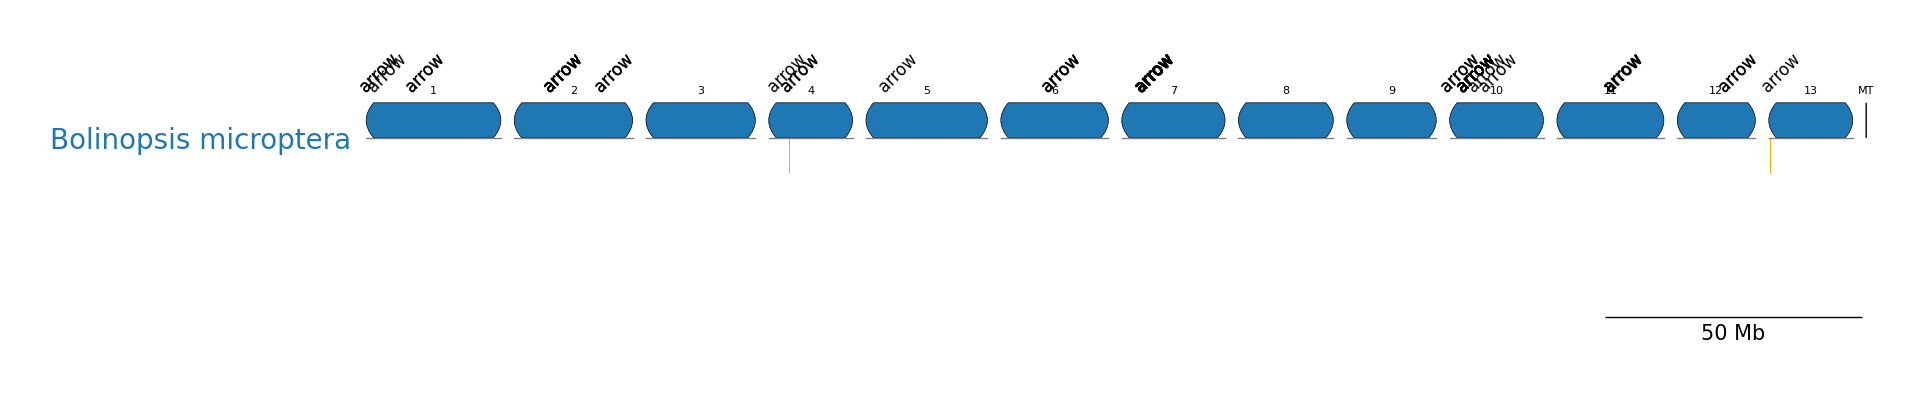

In [206]:
ColorCycler.set_cmap("tab10")

name2chr_segments = chroms # (
#     dict(
#     chimp=dict(chr1=224244399, chr2A=108022953, chr2B=128755405, chr3=196562556, chr4=189151597, chr5=159319378, chr6=168369391, chr7=156046543, chr8=143338810, chr9=110513671, chr10=129809613, chr11=130782606, chr12=130995916, chr13=95599650, chr14=87716528, chr15=80519282, chr16=75912362, chr17=76554115, chr18=74774469, chr19=56733099, chr20=64035432, chr21=33232379, chr22=33698415, chrX=151576176, chrY=26350515),
#     human=dict(chr1=248956422, chr2=242193529, chr3=198295559, chr4=190214555, chr5=181538259, chr6=170805979, chr7=159345973, chr8=145138636, chr9=138394717, chr10=133797422, chr11=135086622, chr12=133275309, chr13=114364328, chr14=107043718, chr15=101991189, chr16=90338345, chr17=83257441, chr18=80373285, chr19=58617616, chr20=64444167, chr21=46709983, chr22=50818468, chrX=156040895, chrY=57227415),
#     mouse=dict(chr1=195471971, chr2=182113224, chr3=160039680, chr4=156508116, chr5=151834684, chr6=149736546, chr7=145441459, chr8=129401213, chr9=124595110, chr10=130694993, chr11=122082543, chr12=120129022, chr13=120421639, chr14=124902244, chr15=104043685, chr16=98207768, chr17=94987271, chr18=90702639, chr19=61431566, chrX=171031299, chrY=91744698),
# ))

gv = GenomeViz(fig_track_height=0.7, feature_track_ratio=0.15, track_align_type="center")
gv.set_scale_bar(ymargin=2)

for name, chr_segments in name2chr_segments.items():
    color = ColorCycler()
    # Set chromosomes as segments
    track = gv.add_feature_track(
        name, chr_segments, space=0.01, align_label=False, label_kws=dict(color=color),
    )

    for seg in track.segments:
        seg.add_feature(
            seg.start,
            seg.end,
            plotstyle="rbox",
            fc=color,
            ec="black",
            lw=0.5,
            label=seg.name.replace("chr", ""),
            text_kws=dict(rotation=0, size=8, color="black", vpos="top", hpos="center"),
        )

    for query in blast_records_list:
        for hit in query:
            hit_id = sanitize_reference_id(hit.target.id)
            row = df[(df["accessionID"] == hit_id) &  (df["species_name"] == name)]
            if row.empty:
                print(f"No match for hit {hit_id} in species {name}")
                continue
            print(row["chrom"].iloc[0], row["start"].iloc[0], row["end"].iloc[0])

            track.segments[int(row["chrom"].iloc[0]) - 1].add_feature(int(row["start"].iloc[0]), int(row["end"].iloc[0]), -1, plotstyle="box", label="arrow")



# gv.add_link(("human", "chr1", 0, 100000000), ("chimp", "chr1", 0, 100000000))
# gv.add_link(("human", "chr2", 0, 120000000), ("chimp", "chr2A", 0, 108022953), color="lime", curve=True)
# gv.add_link(("human", "chr2", 120000000, 242193529), ("chimp", "chr2B", 0, 128755405), color="lime", curve=True)

fig = gv.plotfig()


In [207]:
print(blast_records[1])

  Query: Query_8100163 (length=195)
         AAA49617.1 antifreeze polypeptide (AFP) precursor [Hemitripterus
         americanus]
   Hits: ----  -----  ----------------------------------------------------------
            #  # HSP  ID + description
         ----  -----  ----------------------------------------------------------
            0      1  gi|2700941652|ref|XM_063837581.1|  PREDICTED: Bolinopsi...
            1      1  gi|2700972406|ref|XM_063826959.1|  PREDICTED: Bolinopsi...
            2      2  gi|2700955919|ref|XM_063818157.1|  PREDICTED: Bolinopsi...
            3      1  gi|2700956383|ref|XM_063818403.1|  PREDICTED: Bolinopsi...
            4      1  gi|2700972404|ref|XM_063826957.1|  PREDICTED: Bolinopsi...
            5      1  gi|2700972402|ref|XM_063826956.1|  PREDICTED: Bolinopsi...
            6      1  gi|2700943352|ref|XM_063832653.1|  PREDICTED: Bolinopsi...
            7      1  gi|2700944192|ref|XM_063833072.1|  PREDICTED: Bolinopsi...
            8      1

In [72]:
for query in blast_records_list:
    for hit in query:
        hit_id = sanitize_reference_id(hit.target.id)
        row = df[df["accessionID"] == hit_id]
        print(row)

                 accessionID chrom           species_name   start     end  \
LOC134825402  XM_063837581.1     1  Bolinopsis microptera  491081  554815   

                accession  
LOC134825402  NC_087072.1  
                 accessionID chrom           species_name    start      end  \
LOC134817717  XM_063826959.1     7  Bolinopsis microptera  4412928  4417617   

                accession  
LOC134817717  NC_087078.1  
                 accessionID chrom           species_name     start       end  \
LOC134811364  XM_063818157.1     2  Bolinopsis microptera  17463856  17492435   

                accession  
LOC134811364  NC_087073.1  
                 accessionID chrom           species_name    start      end  \
LOC134811532  XM_063818403.1     2  Bolinopsis microptera  7505332  7507937   

                accession  
LOC134811532  NC_087073.1  
                 accessionID chrom           species_name    start      end  \
LOC134817716  XM_063826957.1     7  Bolinopsis microptera  43

In [233]:
df

,loc,chrom,species_name,start,end,accession,accessionID
0,LOC134814426,4,Bolinopsis microptera,4098515,4119964,NC_087075.1,XM_063822536.1
1,LOC134814511,4,Bolinopsis microptera,1605540,1671361,NC_087075.1,XM_063822663.1
2,LOC134822162,10,Bolinopsis microptera,3074461,3086221,NC_087081.1,XM_063833069.1
3,LOC134825079,13,Bolinopsis microptera,344144,377661,NC_087084.1,XM_063837207.1
4,LOC134824410,12,Bolinopsis microptera,9865385,9866844,NC_087083.1,XM_063836312.1
5,LOC134822539,11,Bolinopsis microptera,10873466,10886829,NC_087082.1,XM_063833648.1
6,LOC134822162,10,Bolinopsis microptera,3074461,3086221,NC_087081.1,XM_063833072.1
7,LOC134817717,7,Bolinopsis microptera,4412928,4417617,NC_087078.1,XM_063826959.1
8,LOC134822376,10,Bolinopsis microptera,32969,38478,NC_087081.1,XM_063833404.1
9,LOC134811229,1,Bolinopsis microptera,9537820,9539178,NC_087072.1,XM_063817999.1


Pandas(loc='LOC134811229', chrom='1', species_name='Bolinopsis microptera', start='9537820', end='9539178', accession='NC_087072.1', accessionID='XM_063817999.1')
Pandas(loc='LOC134825929', chrom='1', species_name='Bolinopsis microptera', start='2007048', end='2010642', accession='NC_087072.1', accessionID='XM_063838129.1')
Pandas(loc='LOC134825402', chrom='1', species_name='Bolinopsis microptera', start='491081', end='554815', accession='NC_087072.1', accessionID='XM_063837581.1')
Pandas(loc='LOC134811532', chrom='2', species_name='Bolinopsis microptera', start='7505332', end='7507937', accession='NC_087073.1', accessionID='XM_063818403.1')
Pandas(loc='LOC134811364', chrom='2', species_name='Bolinopsis microptera', start='17463856', end='17492435', accession='NC_087073.1', accessionID='XM_063818157.1')
Pandas(loc='LOC134814426', chrom='4', species_name='Bolinopsis microptera', start='4098515', end='4119964', accession='NC_087075.1', accessionID='XM_063822536.1')
Pandas(loc='LOC1348145

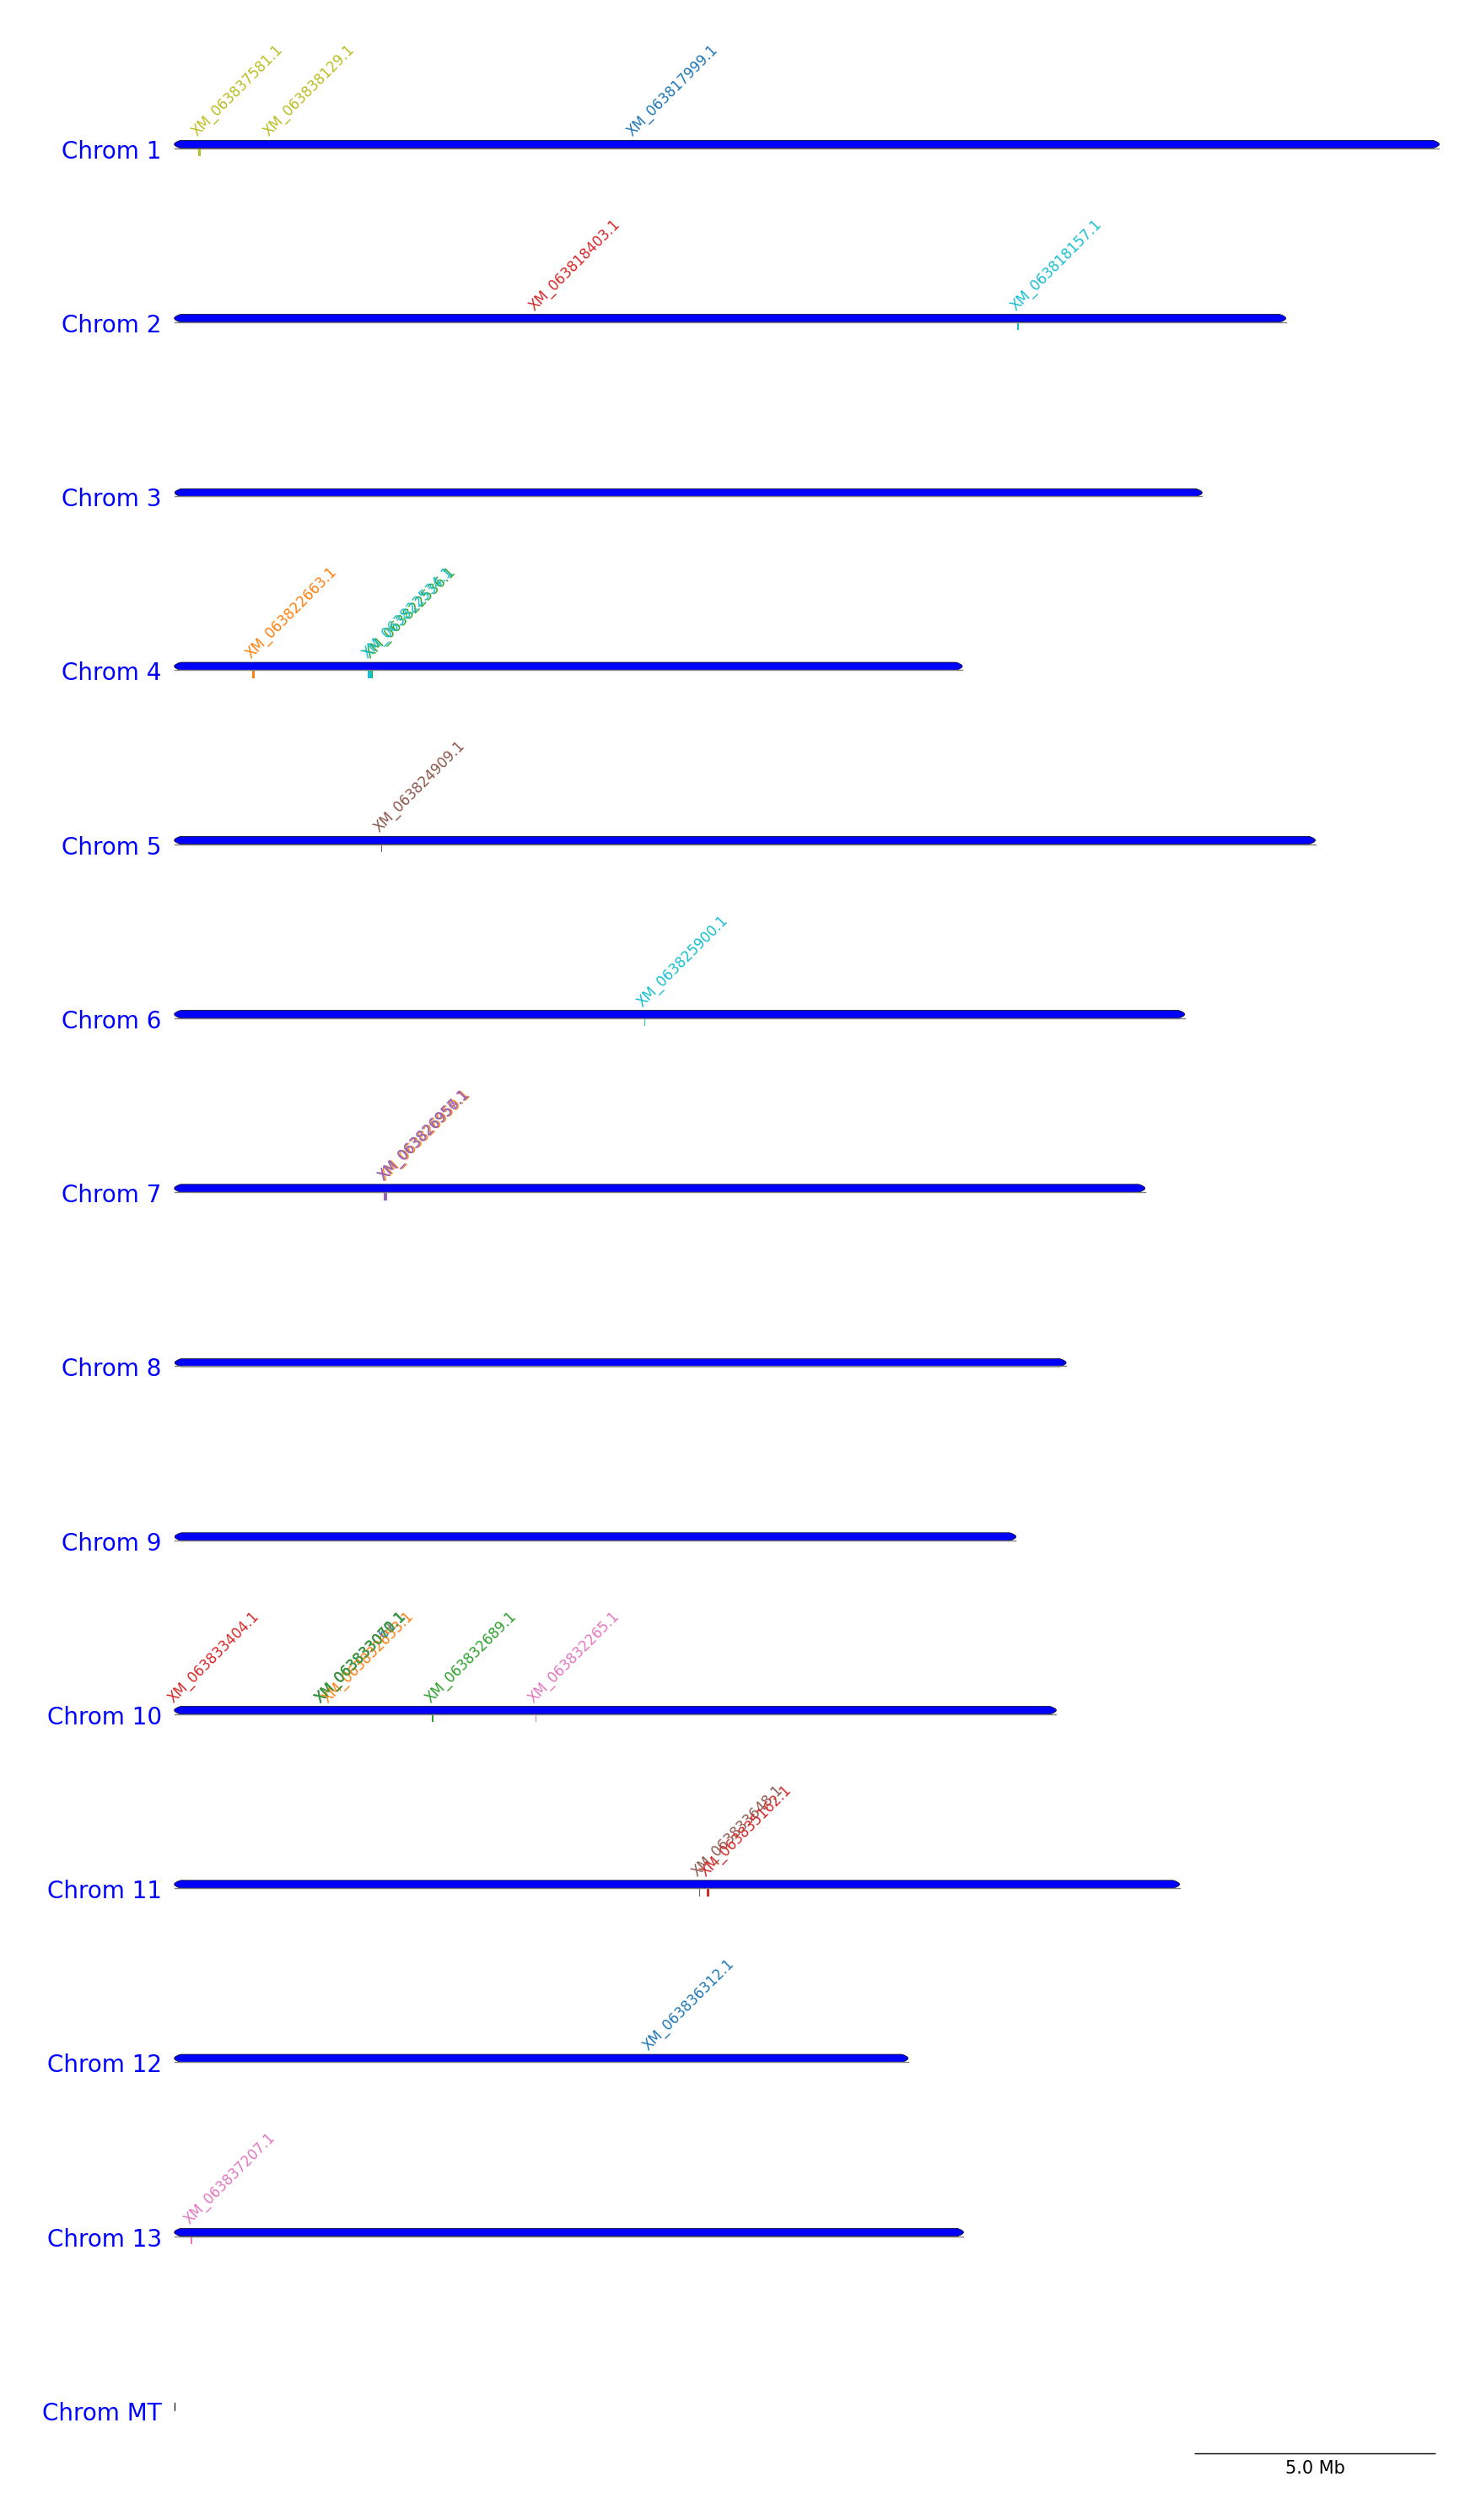

In [236]:

# gbk_files = load_example_genbank_dataset("saccharomyces")
# gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(feature_track_ratio=0.1)
gv.set_scale_bar(ymargin=2.0)

# Plot chromosomes
name = "Bolinopsis microptera"
chromosome_colour = "blue"

unique_accessions = list(set(df["accessionID"]))
unique_colours = {accession : ColorCycler() for accession in unique_accessions}

# for gbk in gbk_list:
for idx, (chrom, chrom_size) in enumerate(chroms[name].items()):
    track = gv.add_feature_track(f"Chrom {chrom}", chrom_size, space=0.01, label_kws=dict(color=chromosome_colour))
    track.set_label(track.name.replace("_", "\n"))
    for segment in track.segments:
        # segment.add_feature(segment.start, segment.end, plotstyle="bigrbox", fc=color, lw=0.5)
        segment.add_feature(
            segment.start,
            segment.end,
            plotstyle="rbox",
            fc=chromosome_colour,
            ec="black",
            lw=0.5,
            # label=segment.name.replace("chr", ""),
            text_kws=dict(rotation=0, size=8, color="black", vpos="top", hpos="center"),
        )

    # for query in blast_records_list:
    #     for hit in query:
    #         hit_id = sanitize_reference_id(hit.target.id)
    #         row = df[(df["accessionID"] == hit_id) &  (df["species_name"] == name)]
    #         if row.empty:
    #             print(f"No match for hit {hit_id} in species {name}")
    #             continue
    #         print(row["chrom"].iloc[0], row["start"].iloc[0], row["end"].iloc[0])

        for row in df[df["chrom"] == str(idx + 1)].itertuples(index=False):
            print(row)
            colour = unique_colours[row.accessionID]
            segment.add_feature(
                int(row.start),
                int(row.end),
                -1,
                fc = colour,
                plotstyle="box",
                label=row.accessionID,
                text_kws=dict(color=colour),
            )

# Run MUMmer alignment
# align_coords = MUMmer(gbk_list).run()

# Plot MUMmer alignment links
# if len(align_coords) > 0:
#     for ac in align_coords:
#         gv.add_link(ac.query_link, ac.ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)
#
# for hit in blast_records_list[2]:
#     id = hit.target.id
#
#     data = df[df["accessionID"] == id][0]
#
#     query_link = (f"Chrom {data['chrom']}", int(data["start"]), int(data["end"]))
#     ref_link = (f"Chrom {data['chrom']}", int(hit.target.start), int(hit.target.end))
#
#     gv.add_link(query_link, ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)

# for ac in align_coords:
#     gv.add_link(ac.query_link, ac.ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)

# for hit in blast_records_list[2]:
#     id = sanitize_reference_id(hit.target.id)
#     data = df[df["accessionID"] == id]
#
#     if data.empty:
#             continue
#
#     query_link = (f"Chrom {str(data['chrom'].iloc[0])}", int(data["start"].iloc[0]), int(data["end"].iloc[0]))
#
#
#     for hit2 in blast_records_list[2]:
#         id2 = sanitize_reference_id(hit2.target.id)
#         data2 = df[df["accessionID"] == id2]
#         if data2.empty:
#             continue
#
#         # if str(data['chrom'].iloc[0]) == f"Chrom {str(data2['chrom'].iloc[0])}":
#         #     continue
#
#         # print(data2)
#         ref_link = (f"Chrom {str(data2['chrom'].iloc[0])}", int(data2["start"].iloc[0]), int(data2["end"].iloc[0]))
#
#         if query_link[0] == ref_link[0]:
#             continue
#
#         gv.add_link(query_link, ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)


fig = gv.plotfig()

In [23]:
for hit in blast_records_list[2]:
    id = sanitize_reference_id(hit.target.id)
    data = df[df["accessionID"] == id]

    if data.empty:
            continue

    query_link = (f"Chrom {str(data['chrom'].iloc[0])}", int(data["start"].iloc[0]), int(data["end"].iloc[0]))


    for hit2 in blast_records_list[2]:
        id2 = sanitize_reference_id(hit2.target.id)
        data2 = df[df["accessionID"] == id2]
        if data2.empty:
            continue

        # print(data2)
        ref_link = (f"Chrom {str(data2['chrom'].iloc[0])}", int(data2["start"].iloc[0]), int(data2["end"].iloc[0]))

        # print(query_link, ref_link)

In [24]:
# record[0]['Entrezgene_xtra-index-terms'][0]

In [25]:
# record[0]['Entrezgene_gene-source']['Gene-source']['Gene-source_src-int']

In [26]:
# record[0]['Entrezgene_gene-source']['Gene-source']['Gene-source_src-int2']

In [27]:
# next(iter(accessions.values()))